# Goa Sales — EDA & Product Segmentation

End-to-end notebook: connect to SQL Server, explore and clean ~72 lakh row sales data, detect anomalies, then engineer features and build a store-sku segmentation model.

## 1. Setup & Imports

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Connect to SQL Server & Load Data

Pulls the full `final_sales` table (71,76,819 rows) directly via `pyodbc` — bypasses Excel/CSV row limits entirely.

In [2]:
import pyodbc as pdb
import pandas as pd

connection = ("Driver={ODBC Driver 17 for SQL Server};"
              "Server=ITDSTANDBY-LAP\\MSSQLSERVER01;"
              "Database=Sales_New;"
              "Trusted_Connection=yes;")

con = pdb.connect(connection)

In [ ]:
query = "SELECT * FROM final_sales"
df = pd.read_sql(query, con)

df.head()

C:\Users\ITDSTANDBY\AppData\Local\Temp\ipykernel_17864\1619539229.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con)


## 3. Initial Data Exploration

Shape, dtypes, and category/sub-category value counts to get a first feel for the data.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7176819 entries, 0 to 7176818
Data columns (total 17 columns):
 #   Column        Dtype         
---  ------        -----         
 0   STORE         int64         
 1   custgroup     int64         
 2   itemid        object        
 3   itemname      object        
 4   ctg           object        
 5   subctg        object        
 6   packsize      int64         
 7   Generic_Flag  object        
 8   BILLNO        object        
 9   BILLDATETIME  datetime64[ns]
 10  SALEQTY       int64         
 11  BILLDATE      object        
 12  SALEVAL       float64       
 13  DISCOUNT      float64       
 14  BILLS         int64         
 15  MAXSALEQTY    int64         
 16  OFFERFLAG     object        
dtypes: datetime64[ns](1), float64(2), int64(6), object(8)
memory usage: 930.8+ MB


In [ ]:
df.shape

(7176819, 17)

In [ ]:
# Count of orders subcategory wise
df["subctg"].value_counts()

subctg
TABLET           2340506
PRIVATE LABEL     995629
PERSONAL CARE     669946
OTC               502819
CAPSULE           372285
                  ...   
FOAM                   8
CAKE                   6
STICKS                 5
OTHERS                 2
PEN                    2
Name: count, Length: 141, dtype: int64

In [ ]:
# Count of orders placed by category
df["ctg"].value_counts()

ctg
PHARMA                 3592789
FMCG                   2334121
PRIVATE LABEL           996460
SURGICAL                115257
CIRCLE SUBSCRIPTION      98095
AYURVEDIC                40028
STATIONERY                  69
Name: count, dtype: int64

## 4. Data Cleaning

Handle missing values (`DISCOUNT`, `SALEVAL`) and check for duplicate rows.

In [ ]:
#replaced 0 with no discount instead of null value
df['DISCOUNT'] = df['DISCOUNT'].fillna(0)

In [ ]:
df.isna().sum()

STORE              0
custgroup          0
itemid             0
itemname           0
ctg                0
subctg             0
packsize           0
Generic_Flag       0
BILLNO             0
BILLDATETIME       0
SALEQTY            0
BILLDATE           0
SALEVAL         6834
DISCOUNT           0
BILLS              0
MAXSALEQTY         0
OFFERFLAG          0
dtype: int64

In [ ]:
# by using stastical mean and median filling the null values in saleval
df['SALEVAL'] = df['SALEVAL'].fillna(df['SALEVAL'].median())

In [ ]:
df.isna().sum()

STORE           0
custgroup       0
itemid          0
itemname        0
ctg             0
subctg          0
packsize        0
Generic_Flag    0
BILLNO          0
BILLDATETIME    0
SALEQTY         0
BILLDATE        0
SALEVAL         0
DISCOUNT        0
BILLS           0
MAXSALEQTY      0
OFFERFLAG       0
dtype: int64

In [ ]:
# checks duplicate values
df.duplicated().sum()

np.int64(0)

In [ ]:
#summary of the data
df.describe()

,STORE,custgroup,packsize,BILLDATETIME,SALEQTY,SALEVAL,DISCOUNT,BILLS,MAXSALEQTY
count,7.176819e+06,7.176819e+06,7.176819e+06,7176819,7.176819e+06,7.176819e+06,7.176819e+06,7176819.0,7.176819e+06
mean,2.005794e+04,3.998247e+03,1.861120e+01,2025-06-24 07:05:25.245300224,7.715706e+00,1.915021e+02,2.254795e+01,1.0,7.508623e+00
min,1.477500e+04,0.000000e+00,1.000000e+00,2024-01-01 00:25:00,-7.200000e+02,-2.062500e+04,-3.815620e+03,1.0,0.000000e+00
25%,1.775000e+04,1.020000e+02,1.000000e+00,2024-12-20 22:57:30,1.000000e+00,5.000000e+01,0.000000e+00,1.0,1.000000e+00
50%,1.869100e+04,4.851000e+03,1.000000e+00,2025-07-29 10:15:00,1.000000e+00,1.095000e+02,0.000000e+00,1.0,1.000000e+00
75%,2.524200e+04,7.661000e+03,1.000000e+01,2026-01-17 16:13:00,1.000000e+01,2.156000e+02,0.000000e+00,1.0,1.000000e+01
max,2.587800e+04,1.030500e+04,1.050000e+03,2026-06-30 23:53:00,3.500000e+03,1.031250e+05,2.979800e+04,1.0,2.445000e+03
std,3.326257e+03,3.692480e+03,6.318659e+01,NaN,1.406851e+01,3.441376e+02,8.389293e+01,0.0,1.300843e+01


## 5. Store & Category-wise Analysis

Sales by store, by item, top stores, top products, and their visualizations.

In [ ]:
df.groupby('STORE')['SALEVAL'].mean().sort_values()

STORE
18192     76.506680
18494    115.870890
18158    119.283676
17976    123.345604
17657    126.750418
17378    133.889663
18956    137.738981
25246    145.542148
15475    148.742378
25300    148.965525
18341    152.248810
25878    156.314047
17772    156.341071
25874    157.915368
25244    160.314291
25248    160.994212
16028    161.610571
17680    162.447848
18206    162.992627
19095    167.083323
14775    168.250282
18312    171.805290
25872    173.041879
16916    174.977228
25247    175.034830
17439    175.434585
18387    177.817208
19096    178.668415
15994    184.579567
25876    185.759062
17681    186.882794
18896    187.630856
18670    188.329481
18692    188.923606
14783    189.868195
16070    191.974721
25242    192.413779
25243    194.355825
25299    195.823699
18691    197.198261
17947    199.069477
25875    199.874173
16257    201.813180
18281    205.444487
25249    206.840057
17530    208.399597
18378    209.120215
14782    214.175110
19076    214.301418
17741    215.0

In [ ]:
df.groupby('itemname')['DISCOUNT'].mean().sort_values()

itemname
MYOTAN 80MG TAB 10'S                       -5.580000
LITAL SYRUP 200ML                           0.000000
MORR 7.5% SOLUTION 60ML                     0.000000
MORR F 3% SOLUTION 60ML                     0.000000
MORR PRO 60ML HAIR SERUM                    0.000000
                                            ...     
EXEMPTIA 40MG/0.8ML INJ                  4687.500000
ENDOBLOC-T KIT TAB                       5369.835175
PROGRAF 1MG CAP 10'S                     5665.950195
MOUNJARO KWIKPEN 12.5MG PFP INJ 0.6ML    6082.513989
MADOPAR 250MG TAB 10'S                   7484.689941
Name: DISCOUNT, Length: 24592, dtype: float64

In [ ]:
# Before/after cleaning summary
original_count = df.shape[0]

# Drop exact duplicate rows found earlier
dup_count = df.duplicated().sum()
df = df.drop_duplicates()

cleaned_count = df.shape[0]

print(f"Original rows: {original_count}")
print(f"Duplicate rows removed: {dup_count}")
print(f"Rows after cleaning: {cleaned_count}")
print(f"Nulls remaining:\n{df.isna().sum()[df.isna().sum() > 0]}")

In [ ]:
top_stores = (df.groupby('STORE')['SALEVAL']
                .sum()
                .sort_values(ascending=False)
                .head(5))

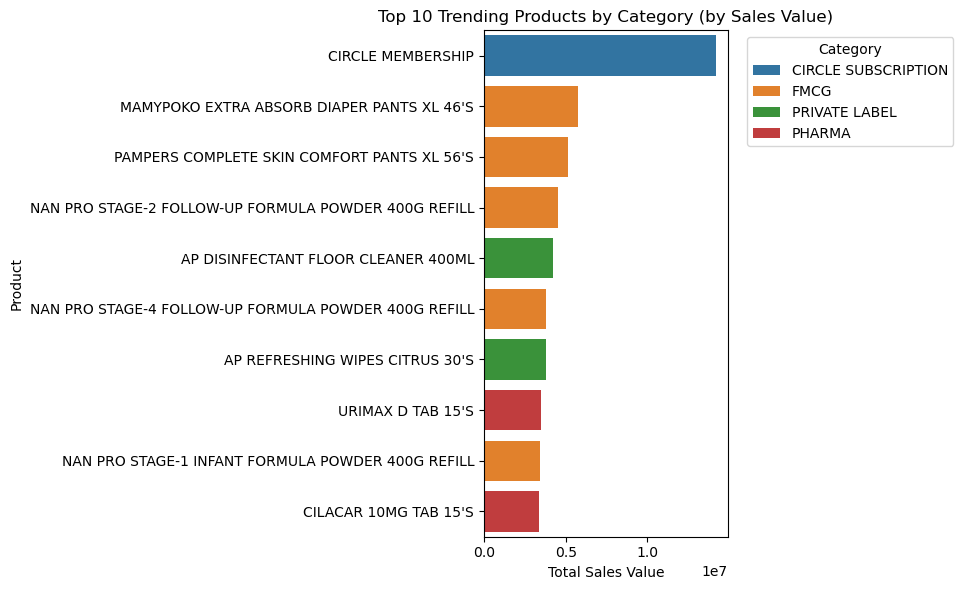

In [ ]:
# Top 10 Trending Products by Category
top_products = (df.groupby(['ctg', 'itemname'])['SALEVAL']
                   .sum()
                   .reset_index()
                   .sort_values('SALEVAL', ascending=False)
                   .head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=top_products, x='SALEVAL', y='itemname', hue='ctg', dodge=False)
plt.title('Top 10 Trending Products by Category (by Sales Value)')
plt.xlabel('Total Sales Value')
plt.ylabel('Product')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\ITDSTANDBY\AppData\Local\Temp\ipykernel_14620\4016001093.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


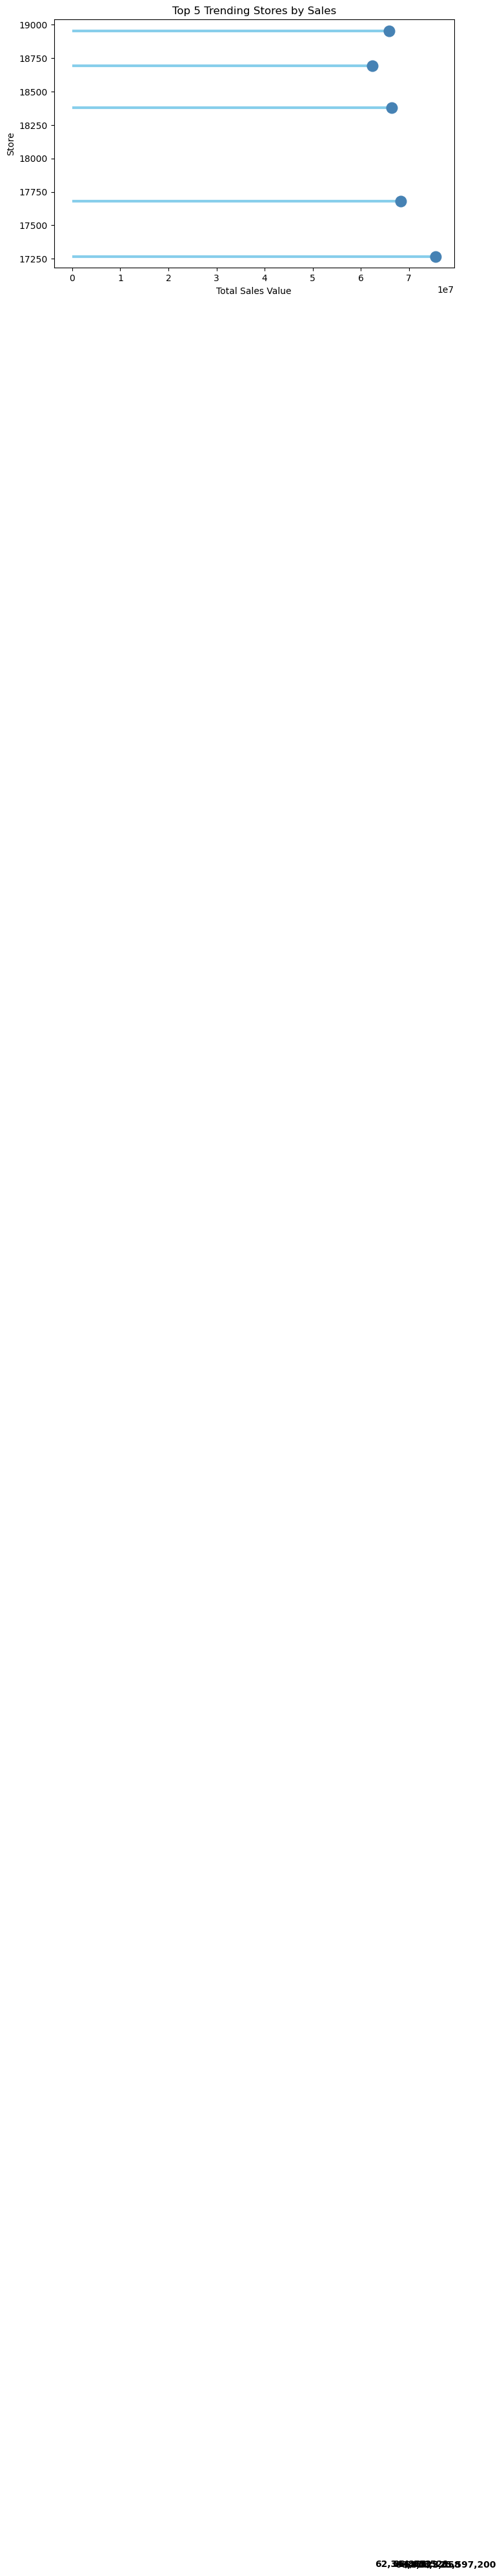

In [ ]:
# Top 5 Trending Stores by Sales
plt.figure(figsize=(8, 5))
plt.hlines(y=top_stores.index, xmin=0, xmax=top_stores.values, color='skyblue', linewidth=3)
plt.plot(top_stores.values, top_stores.index, "o", markersize=12, color='steelblue')

for i, v in enumerate(top_stores.values):
    plt.text(v + (v*0.01), i, f'{v:,.0f}', va='center', fontweight='bold')

plt.title('Top 5 Trending Stores by Sales')
plt.xlabel('Total Sales Value')
plt.ylabel('Store')
plt.tight_layout()
plt.show()

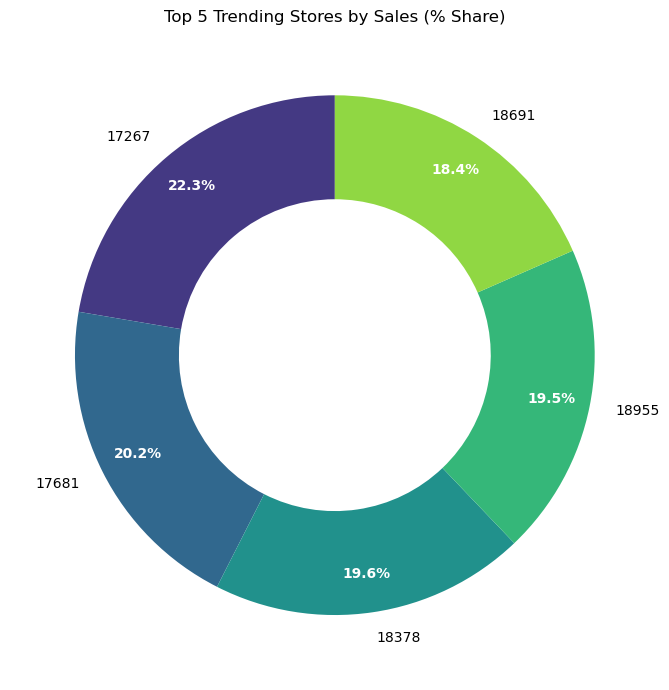

In [ ]:
# by Sales Share
colors = sns.color_palette('viridis', len(top_stores))

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    top_stores.values,
    labels=top_stores.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.85,
    wedgeprops=dict(width=0.4)
)
plt.setp(autotexts, size=10, weight='bold', color='white')
ax.set_title('Top 5 Trending Stores by Sales (% Share)')
plt.tight_layout()
plt.show()

C:\Users\ITDSTANDBY\AppData\Local\Temp\ipykernel_14620\3699073749.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_stores.index, y=top_stores.values, palette='mako')


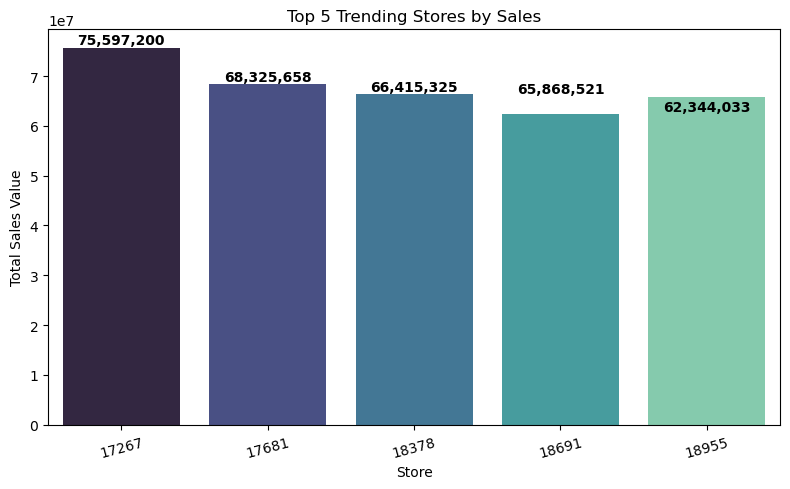

In [ ]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=top_stores.index, y=top_stores.values, palette='mako')

for i, v in enumerate(top_stores.values):
    ax.text(i, v + (v*0.01), f'{v:,.0f}', ha='center', fontweight='bold')

plt.title('Top 5 Trending Stores by Sales')
plt.xlabel('Store')
plt.ylabel('Total Sales Value')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
!pip install squarify

## 6. Time-Based Analysis

Month-over-month growth, year-wise trends by category, weekly patterns, and time-of-day sales behavior.

In [ ]:
df['BILLDATE'] = pd.to_datetime(df['BILLDATE'])

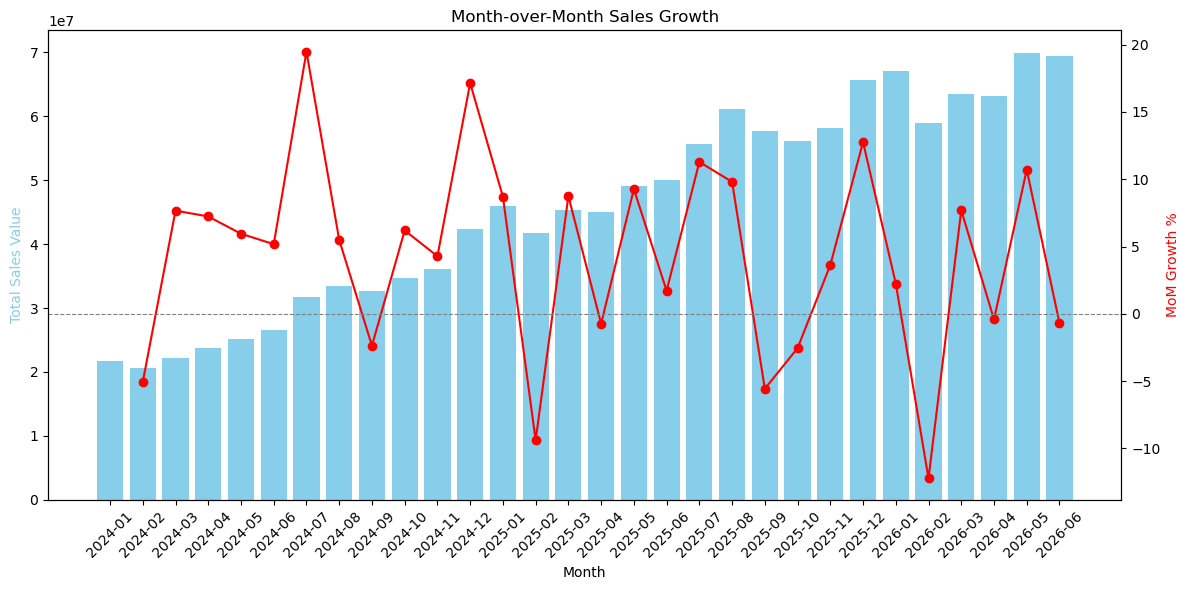

In [ ]:
# MoM (Month-over-Month) Growth of Sales
df['YearMonth'] = df['BILLDATE'].dt.to_period('M')

mom_sales = df.groupby('YearMonth')['SALEVAL'].sum().reset_index()
mom_sales['YearMonth'] = mom_sales['YearMonth'].astype(str)
mom_sales['MoM_Growth_%'] = mom_sales['SALEVAL'].pct_change() * 100

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(mom_sales['YearMonth'], mom_sales['SALEVAL'], color='skyblue', label='Sales Value')
ax1.set_xlabel('Month')
ax1.set_ylabel('Total Sales Value', color='skyblue')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(mom_sales['YearMonth'], mom_sales['MoM_Growth_%'], color='red', marker='o', label='MoM Growth %')
ax2.set_ylabel('MoM Growth %', color='red')
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)

plt.title('Month-over-Month Sales Growth')
fig.tight_layout()
plt.show()

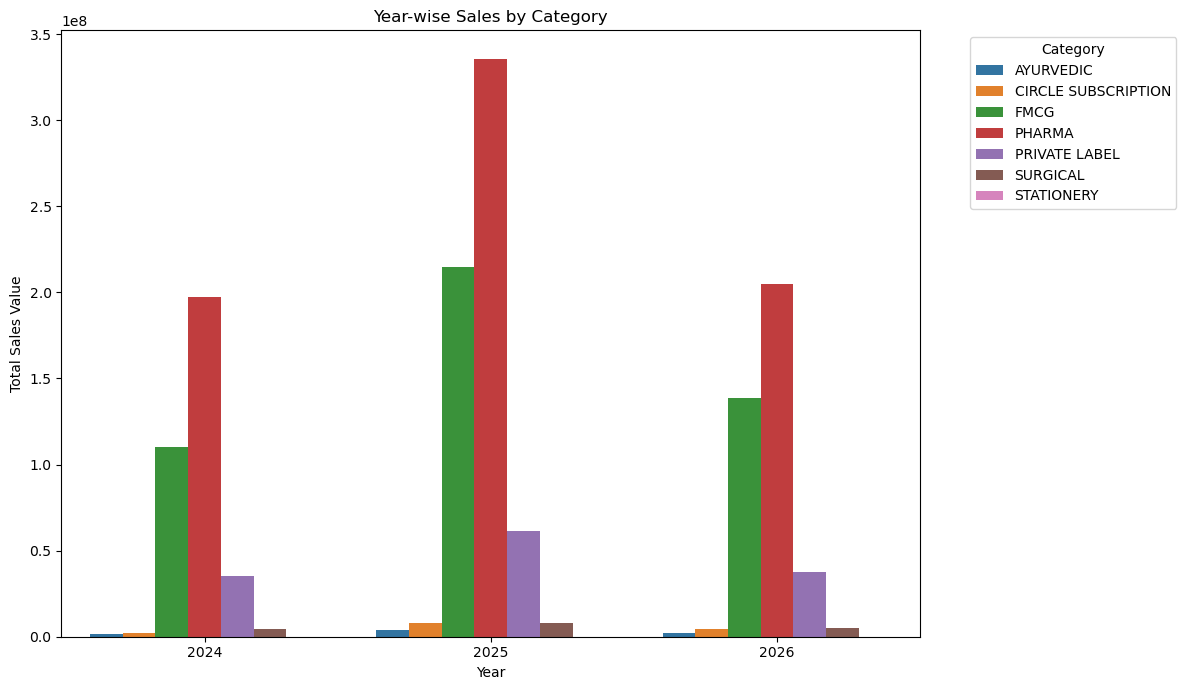

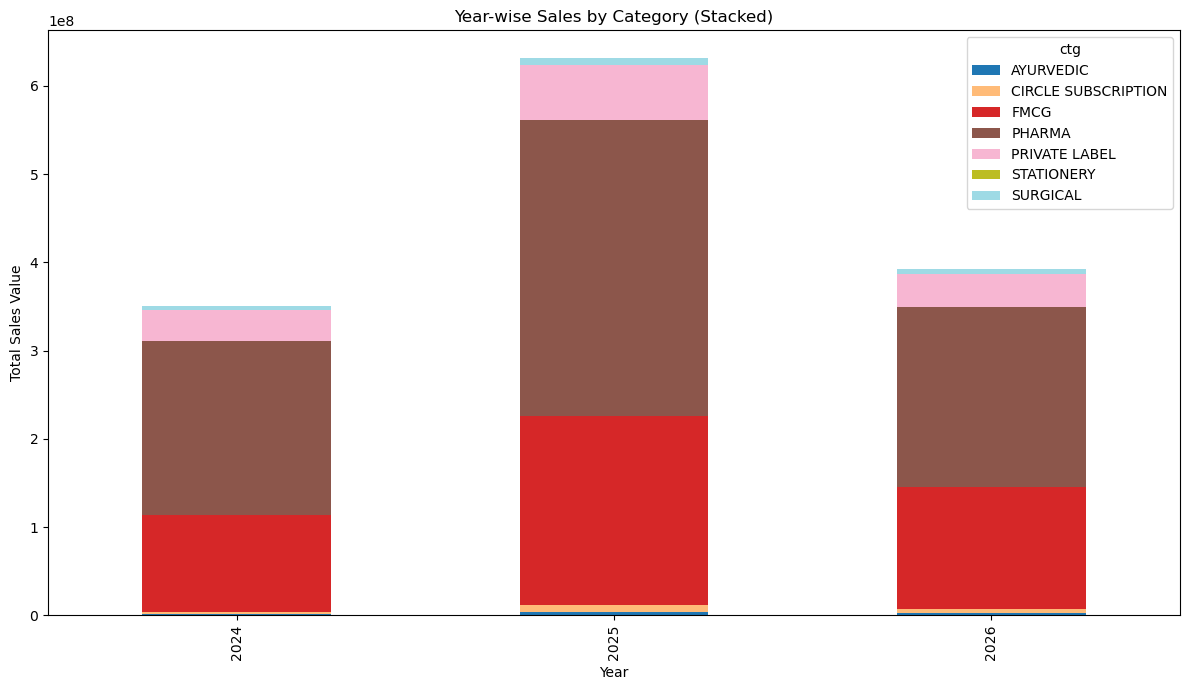

In [ ]:
# Year-wise Sales by Category
df['Year'] = df['BILLDATE'].dt.year

year_cat_sales = df.groupby(['Year', 'ctg'])['SALEVAL'].sum().reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(data=year_cat_sales, x='Year', y='SALEVAL', hue='ctg')
plt.title('Year-wise Sales by Category')
plt.xlabel('Year')
plt.ylabel('Total Sales Value')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Alternative: stacked bar view
pivot = year_cat_sales.pivot(index='Year', columns='ctg', values='SALEVAL').fillna(0)
pivot.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab20')
plt.title('Year-wise Sales by Category (Stacked)')
plt.ylabel('Total Sales Value')
plt.tight_layout()
plt.show()

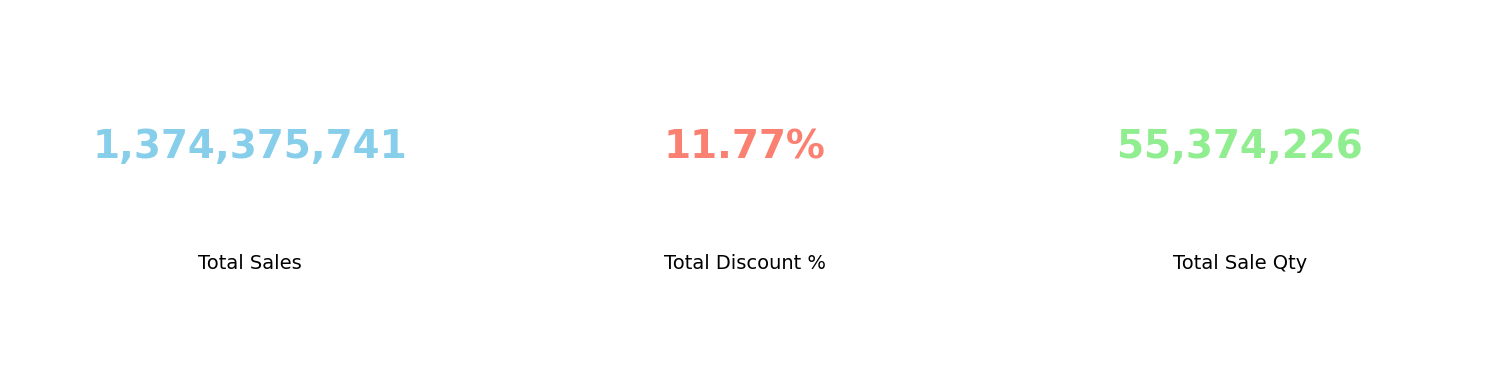

In [ ]:
# Summary Box: Total Sales, Total Discount %, and SaleQty
total_sales = df['SALEVAL'].sum()
total_discount_pct = (df['DISCOUNT'].sum() / df['SALEVAL'].sum()) * 100
total_saleqty = df['SALEQTY'].sum()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = [
    ('Total Sales', f'{total_sales:,.0f}', 'skyblue'),
    ('Total Discount %', f'{total_discount_pct:.2f}%', 'salmon'),
    ('Total Sale Qty', f'{total_saleqty:,.0f}', 'lightgreen')
]

for ax, (label, value, color) in zip(axes, metrics):
    ax.text(0.5, 0.6, value, fontsize=28, fontweight='bold', ha='center', color=color)
    ax.text(0.5, 0.3, label, fontsize=14, ha='center')
    ax.axis('off')
    ax.set_facecolor(color)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(color)
        spine.set_linewidth(2)

plt.tight_layout()
plt.show()

C:\Users\ITDSTANDBY\AppData\Local\Temp\ipykernel_14620\1649524775.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_demand.values, y=top_demand.index, palette='crest')


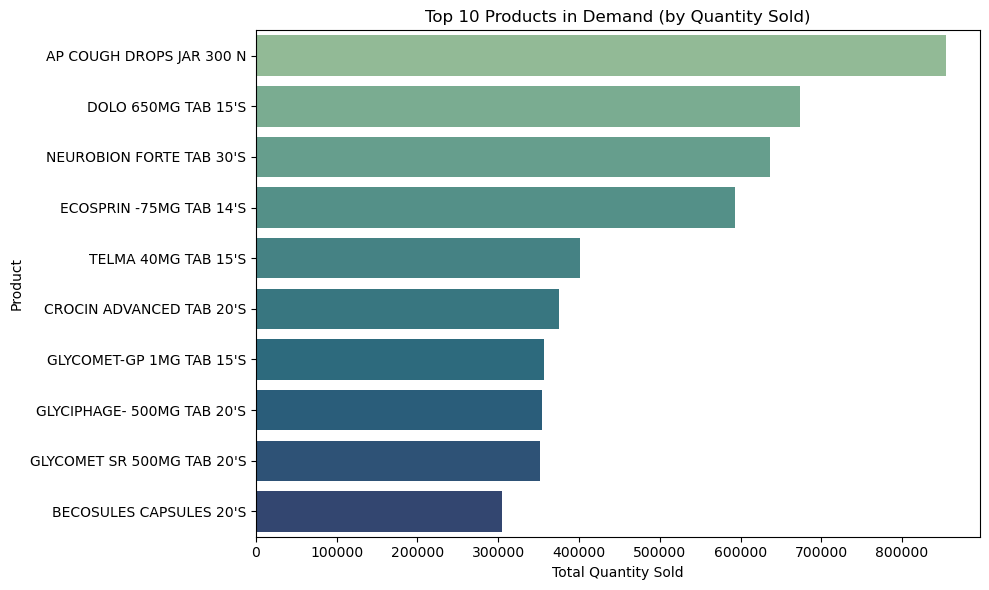

In [ ]:
# Top Demand
top_demand = (df.groupby('itemname')['SALEQTY']
                .sum()
                .sort_values(ascending=False)
                .head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x=top_demand.values, y=top_demand.index, palette='crest')
plt.title('Top 10 Products in Demand (by Quantity Sold)')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

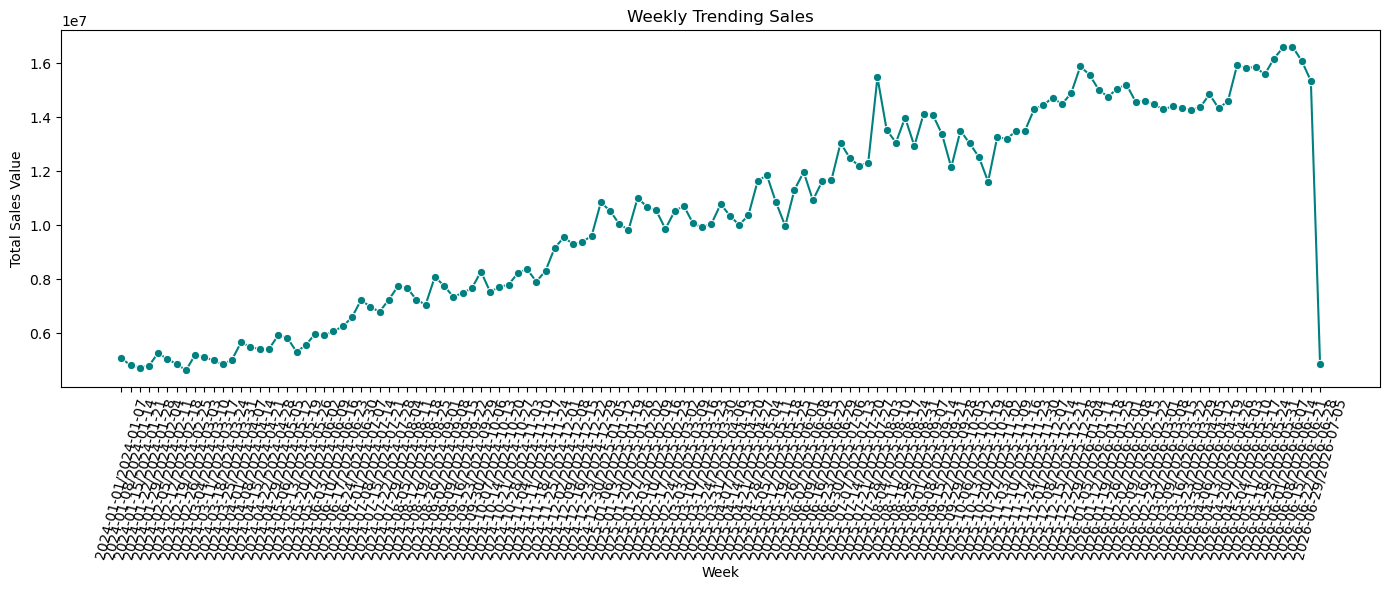

In [ ]:
# Weekly Sales
df['Week'] = df['BILLDATE'].dt.to_period('W').astype(str)

weekly_sales = df.groupby('Week')['SALEVAL'].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=weekly_sales, x='Week', y='SALEVAL', marker='o', color='teal')
plt.title('Weekly Trending Sales')
plt.xlabel('Week')
plt.ylabel('Total Sales Value')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

C:\Users\ITDSTANDBY\AppData\Local\Temp\ipykernel_14620\1158644382.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq_product.values, y=freq_product.index, palette='flare')


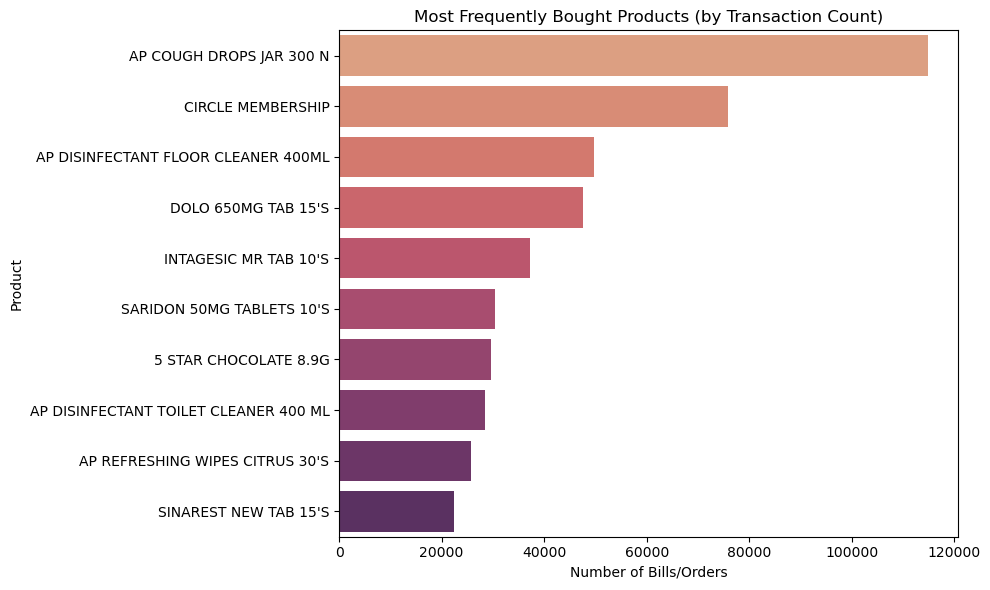

In [ ]:
# Most frequently brought Product 
freq_product = (df.groupby('itemname')['BILLNO']
                   .nunique()
                   .sort_values(ascending=False)
                   .head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x=freq_product.values, y=freq_product.index, palette='flare')
plt.title('Most Frequently Bought Products (by Transaction Count)')
plt.xlabel('Number of Bills/Orders')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

In [ ]:
# day category function

# Ensure BILLDATETIME is a proper datetime dtype before using .dt accessor
df['BILLDATETIME'] = pd.to_datetime(df['BILLDATETIME'])

def get_time_period(hour):
    if 5 <= hour < 12:
        return 'Morning/Day'
    elif 12 <= hour < 17:
        return 'Afternoon'
    else:
        return 'Night'

df['TimePeriod'] = df['BILLDATETIME'].dt.hour.apply(get_time_period)

C:\Users\ITDSTANDBY\AppData\Local\Temp\ipykernel_14620\1608586480.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=period_sales.index, y=period_sales.values, palette=['#FFD700', '#FF8C00', '#191970'])


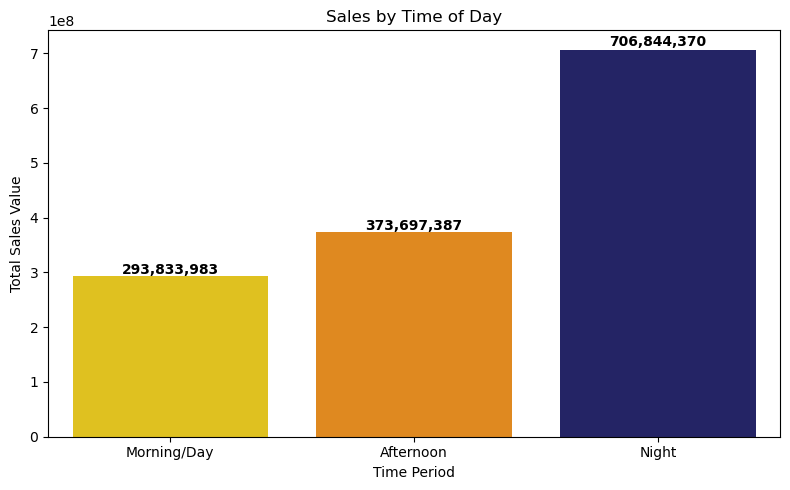

In [ ]:
# comparision day afternoon and night
period_sales = df.groupby('TimePeriod')['SALEVAL'].sum().reindex(['Morning/Day', 'Afternoon', 'Night'])

plt.figure(figsize=(8, 5))
sns.barplot(x=period_sales.index, y=period_sales.values, palette=['#FFD700', '#FF8C00', '#191970'])
plt.title('Sales by Time of Day')
plt.xlabel('Time Period')
plt.ylabel('Total Sales Value')
for i, v in enumerate(period_sales.values):
    plt.text(i, v + (v*0.01), f'{v:,.0f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\ITDSTANDBY\AppData\Local\Temp\ipykernel_14620\2085289887.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_day.values, y=top_day.index.astype(str), palette='YlOrBr_r')


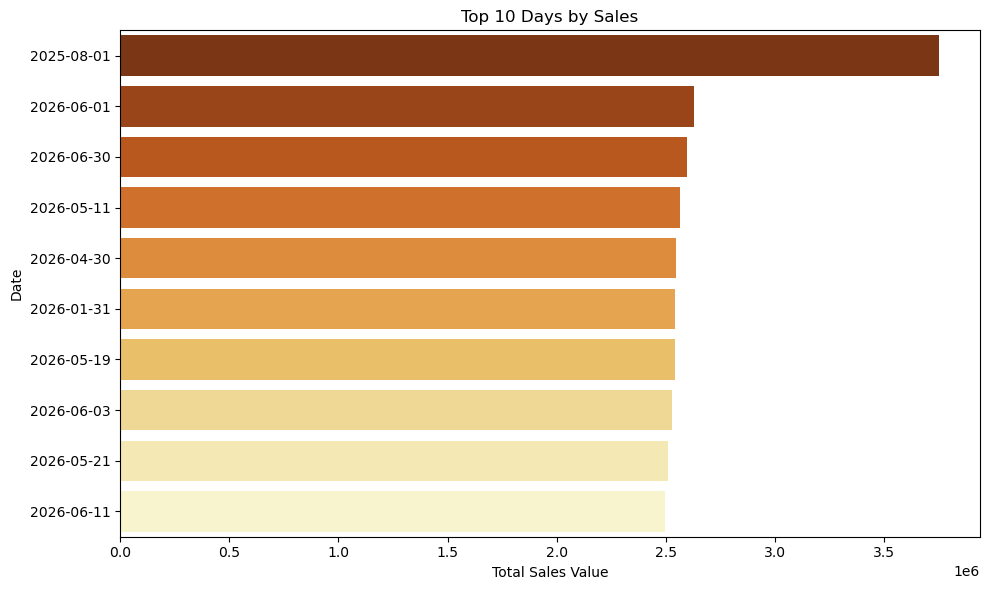

In [ ]:
# Top day Sales
top_day = (df.groupby('BILLDATE')['SALEVAL']
             .sum()
             .sort_values(ascending=False)
             .head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x=top_day.values, y=top_day.index.astype(str), palette='YlOrBr_r')
plt.title('Top 10 Days by Sales')
plt.xlabel('Total Sales Value')
plt.ylabel('Date')
plt.tight_layout()
plt.show()

## 7. Outlier & Anomaly Detection

Three independent methods — Winsorization, IQR, MAD z-score, and Isolation Forest — flag unusual transactions, then a consensus flag combines them.

In [ ]:
from scipy.stats.mstats import winsorize

df['saleval_winsorized'] = winsorize(df['SALEVAL'], limits=[0.05, 0.05])

In [ ]:
# IQR Method (true 25th/75th percentile quartiles)
Q1 = df['SALEVAL'].quantile(0.25)
Q3 = df['SALEVAL'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['iqr_outlier'] = ((df['SALEVAL'] < lower_bound) | (df['SALEVAL'] > upper_bound)).astype(int)

print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")
print(f"IQR flagged outliers: {df['iqr_outlier'].sum()}")

In [ ]:
# MAD Z-Score (Modified Z-Score)
# More robust than standard z-score because it uses median instead of mean (less sensitive to outliers).
def mad_zscore(series):
    median = series.median()
    mad = (series - median).abs().median()
    return 0.6745 * (series - median) / mad

df['saleval_mad_z'] = mad_zscore(df['SALEVAL'])

# Sweep thresholds 1-5 to see how sensitive the flag count is to the cutoff
for t in range(1, 6):
    count = (df['saleval_mad_z'].abs() > t).sum()
    print(f"Threshold {t}: {count} flagged ({count/len(df)*100:.2f}%)")

# Final flag uses threshold = 3 (standard convention for modified z-score)
df['anomaly_flag'] = np.where(df['saleval_mad_z'].abs() > 3, 1, 0)

In [ ]:
from sklearn.ensemble import IsolationForest

features = df[['SALEVAL', 'DISCOUNT', 'packsize']].fillna(0)

iso = IsolationForest(contamination=0.05, random_state=42)
df['iso_anomaly'] = iso.fit_predict(features)

# -1 = anomaly, 1 = normal
df['iso_anomaly'] = df['iso_anomaly'].map({1: 0, -1: 1})

In [ ]:
print("MAD flagged:", df['anomaly_flag'].sum())
print("IQR flagged:", df['iqr_outlier'].sum())
print("Isolation Forest flagged:", df['iso_anomaly'].sum())

MAD flagged: 736673
IQR flagged: 44747
Isolation Forest flagged: 358660


### Method Comparison & Consensus

Compare the three anomaly detection methods (MAD z-score, IQR, Isolation Forest) to see how much they agree, and build a consensus flag.

In [ ]:
# Compare overlap between the three anomaly detection methods
comparison = pd.DataFrame({
    'MAD_zscore': df['anomaly_flag'],
    'IQR': df['iqr_outlier'],
    'Isolation_Forest': df['iso_anomaly']
})

# How many methods flagged each row as an anomaly (0-3)
comparison['votes'] = comparison.sum(axis=1)

print("Agreement across methods (number of rows by vote count):")
print(comparison['votes'].value_counts().sort_index())

print("\nRows flagged by ALL 3 methods (high-confidence anomalies):", (comparison['votes'] == 3).sum())
print("Rows flagged by AT LEAST 1 method:", (comparison['votes'] >= 1).sum())
print("Rows flagged by exactly 2 methods:", (comparison['votes'] == 2).sum())

# Consensus flag: treat as anomaly only if 2+ methods agree (reduces false positives from any single method)
df['consensus_anomaly'] = (comparison['votes'] >= 2).astype(int)
print("\nConsensus anomalies (2+ methods agree):", df['consensus_anomaly'].sum())

# Product Segmentation (Store–SKU Level)

Reference plan (2.b): Product Segmentation, grain = Store x SKU, method = Clustering.

Pipeline:
1. Feature Engineering (store-sku level aggregates)
2. ABC classification (value, 70/20/10 Pareto)
3. XYZ classification (demand variability)
4. ABC x XYZ (9 combinations)
5. Demand / quantity bucket
6. Active-day / recency features
7. Rank(Val), Rank(Qty), Final Rank
8. Top / Mid / Tail segmentation (KMeans clustering)
9. Train/Test split
10. Model selection & training
11. Model evaluation
12. Hyperparameter tuning
13. Final model

**Assumption:** grain is (STORE, itemid) — i.e. each store-item combination is treated as one record ("store sku"). If you actually want SKU-level segmentation aggregated across all Goa stores instead, just drop `STORE` from the `groupby` in the feature engineering cell below — everything downstream still works the same way.

## 1. Feature Engineering (Store-SKU level)

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
import joblib

# Reference window for recency / active-day calculations
data_min_date = df['BILLDATE'].min()
data_max_date = df['BILLDATE'].max()
total_period_days = (data_max_date - data_min_date).days + 1

# Aggregate to store-sku grain
sku = df.groupby(['STORE', 'itemid']).agg(
    itemname=('itemname', 'first'),
    ctg=('ctg', 'first'),
    subctg=('subctg', 'first'),
    total_saleval=('SALEVAL', 'sum'),
    total_saleqty=('SALEQTY', 'sum'),
    avg_discount=('DISCOUNT', 'mean'),
    num_bills=('BILLNO', 'nunique'),
    active_days=('BILLDATE', 'nunique'),
    first_sale=('BILLDATE', 'min'),
    last_sale=('BILLDATE', 'max'),
).reset_index()

# Recency / activity features
sku['days_since_first_sale'] = (data_max_date - sku['first_sale']).dt.days
sku['days_since_last_sale']  = (data_max_date - sku['last_sale']).dt.days
sku['active_ratio']    = sku['active_days'] / total_period_days      # how many days active, out of possible days
sku['non_active_days'] = total_period_days - sku['active_days']      # how many days non-active

# Average monthly quantity (for demand bucket)
months_span = max(total_period_days / 30.44, 1)
sku['avg_monthly_qty'] = sku['total_saleqty'] / months_span

# Coefficient of variation of monthly qty (for XYZ classification -> demand stability)
monthly = (df.groupby(['STORE', 'itemid', df['BILLDATE'].dt.to_period('M')])['SALEQTY']
             .sum().reset_index())
cv_tbl = monthly.groupby(['STORE', 'itemid'])['SALEQTY'].agg(['mean', 'std']).reset_index()
cv_tbl['cv_qty'] = (cv_tbl['std'] / cv_tbl['mean']).replace([np.inf, -np.inf], np.nan).fillna(0)
sku = sku.merge(cv_tbl[['STORE', 'itemid', 'cv_qty']], on=['STORE', 'itemid'], how='left')
sku['cv_qty'] = sku['cv_qty'].fillna(0)

print('Store-SKU feature table shape:', sku.shape)
sku.head()

## 2. ABC Classification (by value, 70/20/10)

SKUs are ranked by total sale value, then classified by cumulative % contribution to total revenue — the classic Pareto rule.

In [ ]:
sku = sku.sort_values('total_saleval', ascending=False).reset_index(drop=True)
sku['cum_val_pct'] = sku['total_saleval'].cumsum() / sku['total_saleval'].sum() * 100

def abc_class(pct):
    if pct <= 70:
        return 'A'
    elif pct <= 90:      # next 20% (70-90 cumulative)
        return 'B'
    else:                 # last 10%
        return 'C'

sku['ABC'] = sku['cum_val_pct'].apply(abc_class)
sku['ABC'].value_counts()

## 3. XYZ Classification (demand variability)

X / Y / Z is based on the coefficient of variation (CV) of monthly quantity — how stable vs. erratic demand is, not how much revenue it generates. Thresholds below are the standard textbook convention; adjust if your rubric expects different cutoffs.

In [ ]:
def xyz_class(cv):
    if cv <= 0.5:
        return 'X'   # stable demand
    elif cv <= 1.0:
        return 'Y'   # moderately variable
    else:
        return 'Z'   # highly irregular / sporadic

sku['XYZ'] = sku['cv_qty'].apply(xyz_class)
sku['XYZ'].value_counts()

## 4. ABC x XYZ (9 combinations)

In [ ]:
sku['ABC_XYZ'] = sku['ABC'] + sku['XYZ']

plt.figure(figsize=(8, 5))
order = ['AX','AY','AZ','BX','BY','BZ','CX','CY','CZ']
sns.countplot(data=sku, x='ABC_XYZ', order=order, palette='viridis')
plt.title('SKU Count by ABC-XYZ Segment (9 combinations)')
plt.xlabel('Segment')
plt.ylabel('Number of Store-SKUs')
plt.tight_layout()
plt.show()

sku['ABC_XYZ'].value_counts().reindex(order)

## 5. Demand / Quantity Bucket

In [ ]:
def qty_bucket(q):
    if q >= 200:
        return '200+'
    elif q >= 100:
        return '100-200'
    elif q >= 50:
        return '50-100'
    elif q >= 10:
        return '10-50'
    else:
        return '0-10'

sku['demand_class'] = sku['avg_monthly_qty'].apply(qty_bucket)
sku['demand_class'].value_counts()

## 6. Rank(Val), Rank(Qty), Final Rank

In [ ]:
sku['Rank_Val'] = sku['total_saleval'].rank(ascending=False, method='first').astype(int)
sku['Rank_Qty'] = sku['total_saleqty'].rank(ascending=False, method='first').astype(int)

# Final rank: average of value-rank and qty-rank, then re-ranked into a clean 1..N sequence
sku['Final_Rank'] = ((sku['Rank_Val'] + sku['Rank_Qty']) / 2).rank(method='first').astype(int)

sku[['STORE','itemid','itemname','Rank_Val','Rank_Qty','Final_Rank']].sort_values('Final_Rank').head(10)

## 7. Top / Mid / Tail Segmentation (KMeans clustering)

This is the "AI help" / Cluster step from the plan — instead of a fixed 75/15/10 cutoff, KMeans groups store-skus by value, quantity, activity, and demand stability, and the resulting clusters are labelled Top/Mid/Tail by their average sale value.

In [ ]:
cluster_features = ['total_saleval', 'total_saleqty', 'active_days', 'cv_qty']
X_cluster = sku[cluster_features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
sku['cluster'] = kmeans.fit_predict(X_scaled)

# Map raw cluster ids -> Top / Mid / Tail by average value per cluster
cluster_rank = sku.groupby('cluster')['total_saleval'].mean().sort_values(ascending=False)
tier_map = {cluster_rank.index[0]: 'Top', cluster_rank.index[1]: 'Mid', cluster_rank.index[2]: 'Tail'}
sku['Segment'] = sku['cluster'].map(tier_map)

print((sku['Segment'].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(6, 5))
sns.countplot(data=sku, x='Segment', order=['Top','Mid','Tail'], palette='mako')
plt.title('Store-SKU Count by Segment (Top/Mid/Tail)')
plt.tight_layout()
plt.show()

## 8. Train / Test Split

The clustering step above is unsupervised and has to be rerun on the whole dataset every time. To make segmentation usable in production (e.g. classify a *new* store-sku as Top/Mid/Tail without rerunning KMeans on everything), we train a supervised classifier on the cluster labels — a standard "cluster-then-classify" pattern.

In [ ]:
feature_cols = ['total_saleval', 'total_saleqty', 'active_days', 'active_ratio',
                'cv_qty', 'avg_discount', 'days_since_first_sale']

X = sku[feature_cols].fillna(0)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(sku['Segment'])   # Top/Mid/Tail -> 0/1/2

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)
print('Class distribution (train):', np.bincount(y_train))

## 9. Model Selection & Training

Compare a few standard classifiers with default settings via cross-validation before committing to one.

In [ ]:
candidate_models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, random_state=42),
    'RandomForest':       RandomForestClassifier(random_state=42),
    'GradientBoosting':   GradientBoostingClassifier(random_state=42),
}

# Logistic Regression needs scaled features; tree models don't
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

cv_results = {}
for name, model in candidate_models.items():
    X_tr = X_train_scaled if name == 'LogisticRegression' else X_train
    scores = cross_val_score(model, X_tr, y_train, cv=5, scoring='f1_macro')
    cv_results[name] = scores.mean()
    print(f'{name}: CV F1-macro = {scores.mean():.4f} (+/- {scores.std():.4f})')

best_model_name = max(cv_results, key=cv_results.get)
print('\nBest model by CV score:', best_model_name)

## 10. Model Evaluation (on held-out test set)

In [ ]:
for name, model in candidate_models.items():
    X_tr = X_train_scaled if name == 'LogisticRegression' else X_train
    X_te = X_test_scaled  if name == 'LogisticRegression' else X_test

    model.fit(X_tr, y_train)
    preds = model.predict(X_te)

    print(f'--- {name} ---')
    print('Accuracy:', round(accuracy_score(y_test, preds), 4))
    print(classification_report(y_test, preds, target_names=label_encoder.classes_))
    print()

In [ ]:
# Confusion matrix for the best candidate model
best_model = candidate_models[best_model_name]
X_te_best = X_test_scaled if best_model_name == 'LogisticRegression' else X_test
preds_best = best_model.predict(X_te_best)

cm = confusion_matrix(y_test, preds_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 11. Hyperparameter Tuning

GridSearchCV on the best-performing model family (Random Forest) to squeeze out additional performance.

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 4],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print('Best params:', grid_search.best_params_)
print('Best CV F1-macro:', round(grid_search.best_score_, 4))

## 12. Final Model

Refit with the best hyperparameters, evaluate one more time on the held-out test set, inspect feature importance, and save the model artifact.

In [ ]:
final_model = grid_search.best_estimator_
final_preds = final_model.predict(X_test)

print('Final model test accuracy:', round(accuracy_score(y_test, final_preds), 4))
print('Final model test F1-macro:', round(f1_score(y_test, final_preds, average='macro'), 4))
print()
print(classification_report(y_test, final_preds, target_names=label_encoder.classes_))

# Feature importance
importance = pd.Series(final_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=importance.values, y=importance.index, palette='crest')
plt.title('Feature Importance - Final Segmentation Model')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Save the final model + supporting objects so new store-skus can be scored later
joblib.dump(final_model, 'product_segmentation_model.pkl')
joblib.dump(label_encoder, 'segment_label_encoder.pkl')
joblib.dump(feature_cols, 'segment_feature_cols.pkl')
print('\nSaved: product_segmentation_model.pkl, segment_label_encoder.pkl, segment_feature_cols.pkl')

## 13. Full Segmentation Table

Final store-sku table with everything: ABC, XYZ, ABC_XYZ, demand class, ranks, and clustering-derived segment — ready to export to Power BI or SQL.

In [ ]:
segmentation_output = sku[['STORE','itemid','itemname','ctg','subctg',
                           'total_saleval','total_saleqty','active_days','non_active_days',
                           'days_since_first_sale','days_since_last_sale',
                           'ABC','XYZ','ABC_XYZ','demand_class',
                           'Rank_Val','Rank_Qty','Final_Rank','Segment']]

segmentation_output.to_csv('store_sku_segmentation.csv', index=False)
print('Saved store_sku_segmentation.csv with', len(segmentation_output), 'rows')
segmentation_output.sort_values('Final_Rank').head(10)